In [5]:
import os
print(os.getcwd())

d:\NeuroGuard\notebooks


In [6]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [7]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.data.load_data import(
    load_config, load_dataset
)

from ml.data.validate import DatasetValidator

sns.set_theme(style='whitegrid')

FIGURE_DIR = Path("..artifacts/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
config = load_config("../configs/config.yaml")

df = load_dataset(config)

validator = DatasetValidator(df)

report = validator.generate_report(
    config["model"]["target"]
)

2026-07-06 17:14:14,361 | INFO | Configuation loaded successfully.
2026-07-06 17:14:14,362 | INFO | Loading dataset: 
D:\NeuroGuard\ml\data\raw\stroke_data.csv
2026-07-06 17:14:14,369 | INFO | Dataset loaded successfully.



DATA VALIDATION REPORT

Dataset Shape
{'rows': 5110, 'columns': 12}

Duplicate Rows
0

Missing Values
                   Missing Count  Missing %
bmi                          201       3.93
id                             0       0.00
age                            0       0.00
gender                         0       0.00
hypertension                   0       0.00
heart_disease                  0       0.00
work_type                      0       0.00
ever_married                   0       0.00
Residence_type                 0       0.00
avg_glucose_level              0       0.00
smoking_status                 0       0.00
stroke                         0       0.00

Data Types
                  Data Type  Non Null  Unique
id                    int64      5110    5110
gender                  str      5110       3
age                 float64      5110     104
hypertension          int64      5110       2
heart_disease         int64      5110       2
ever_married            str      5110

In [16]:
display(df.head()) # gives top 5 rows
display(df.sample(5)) # random 5 rows
display(df.describe()) # statistical data
display(df.info()) # data-type and total-entries

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1952,48364,Male,52.0,0,0,Yes,Govt_job,Urban,223.35,27.3,formerly smoked,0
4553,69059,Female,42.0,0,0,Yes,Private,Urban,86.30,20.1,never smoked,0
2254,15255,Female,16.0,0,0,No,Private,Rural,94.03,25.7,never smoked,0
139,30683,Female,75.0,0,0,Yes,Private,Rural,199.20,26.6,Unknown,1
2410,44510,Female,56.0,0,0,Yes,Private,Rural,131.63,27.6,never smoked,0


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


None

,Missing Count,Missing %
bmi,201,3.93
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00


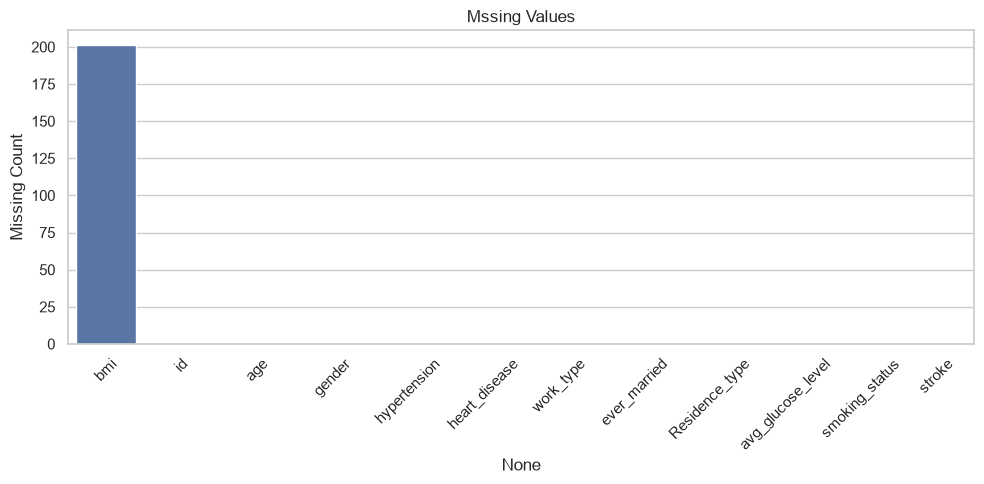

In [17]:
missing = report["missing"]
display(missing)
plt.figure(figsize=(10, 5))
sns.barplot(
    x = missing.index,
    y = missing["Missing Count"]
)
plt.xticks(rotation = 45)
plt.title("Mssing Values")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "missing_value.png")
plt.show()

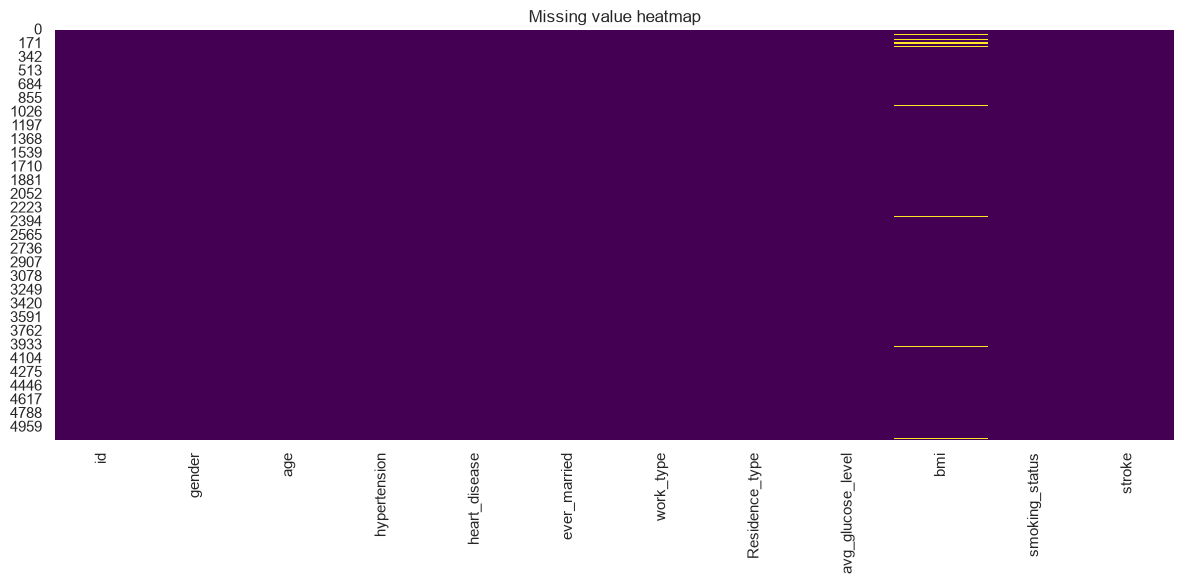

In [20]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),
    cbar = False,
    cmap='viridis'
)

plt.title("Missing value heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "missing_heatmap.png")
plt.show()

2026-07-06 20:02:13,858 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 20:02:13,863 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


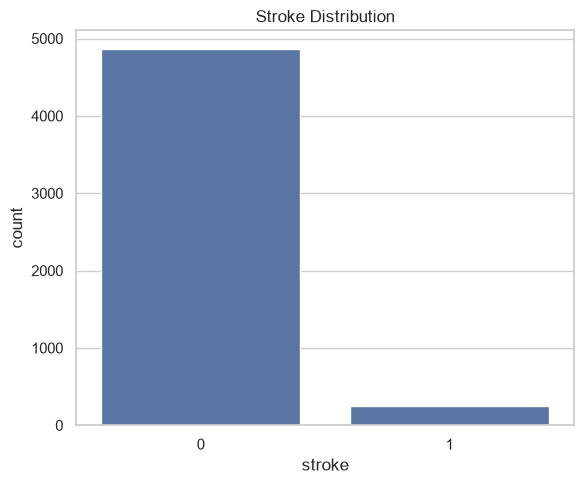

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [21]:
plt.figure(figsize=(6, 5))
sns.countplot(
    data = df,
    x = "stroke"
)

plt.title("Stroke Distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stroke_distribution.png')
plt.show()

print(df['stroke'].value_counts(normalize=True)*100)

In [22]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='str')

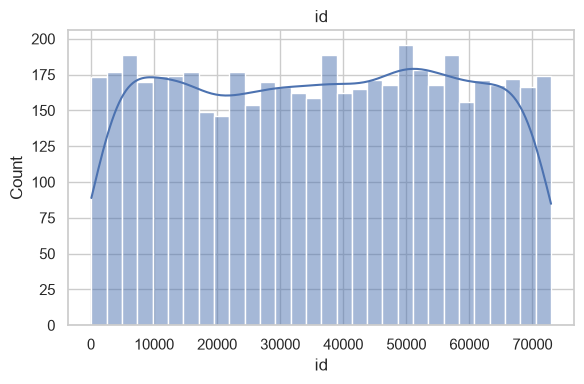

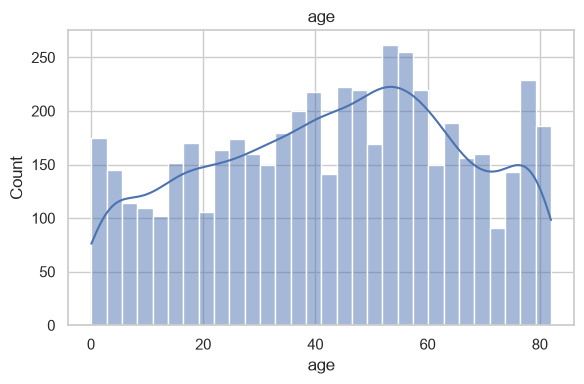

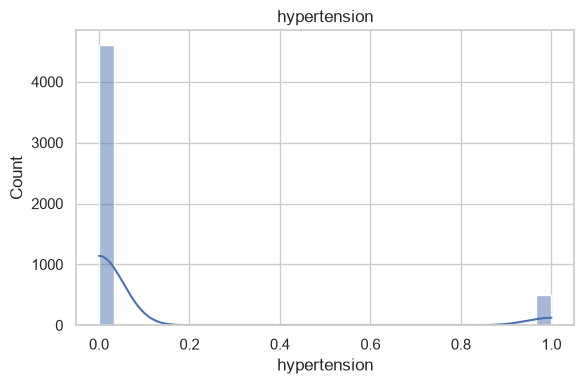

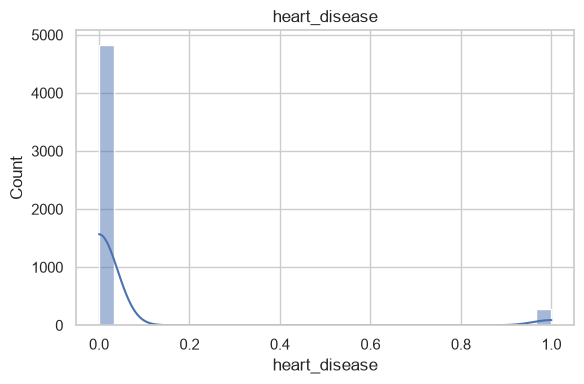

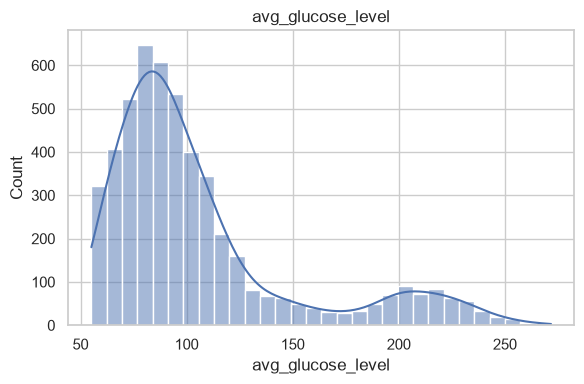

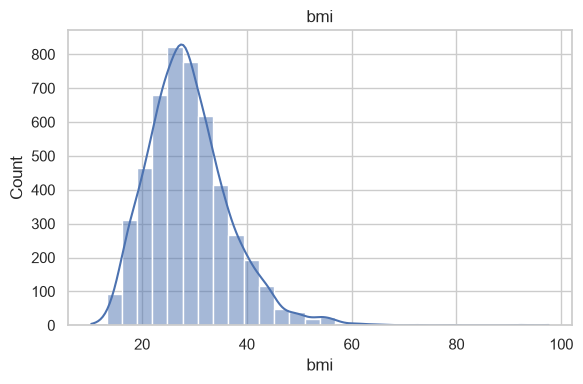

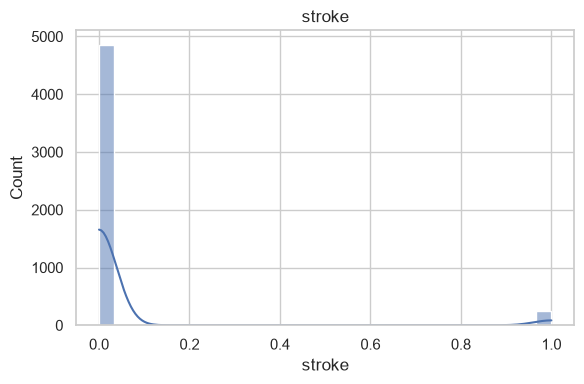

In [23]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df[col],
        kde = True,
        bins = 30
    )

    plt.title(col)
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{col}_hist.png"
    )

    plt.show()

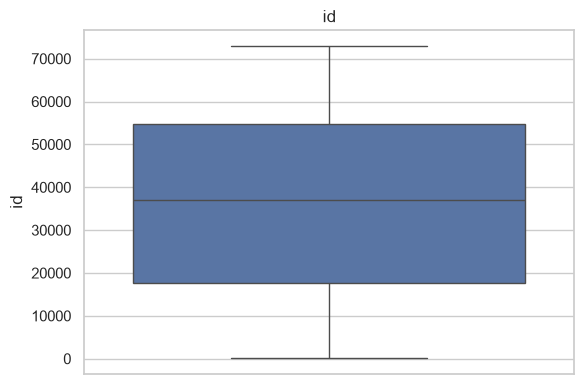

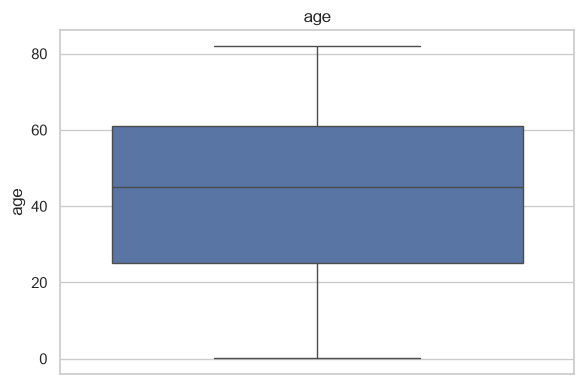

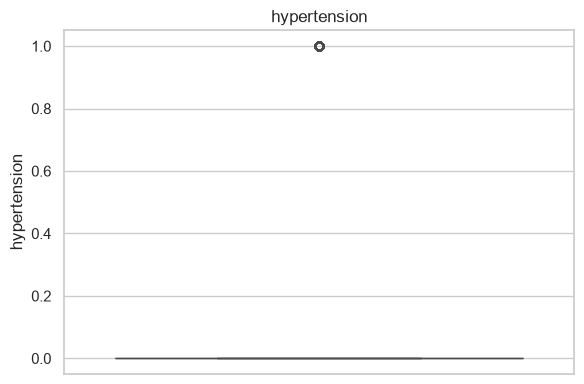

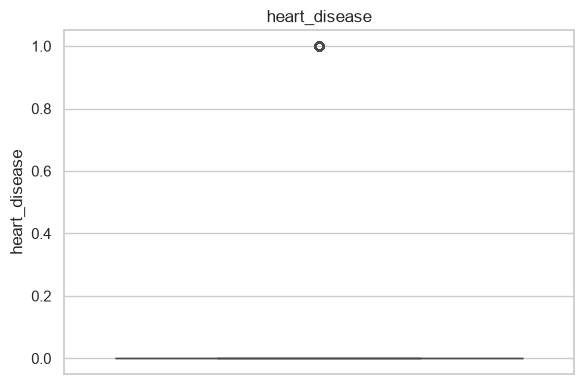

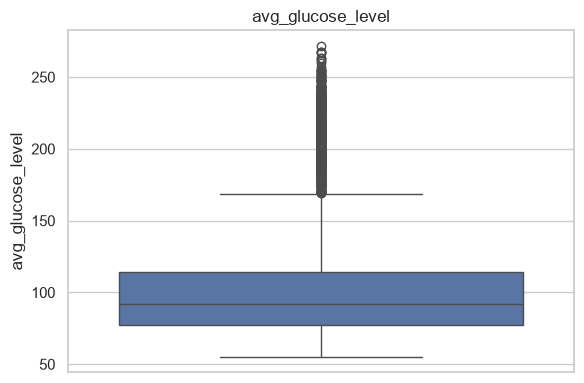

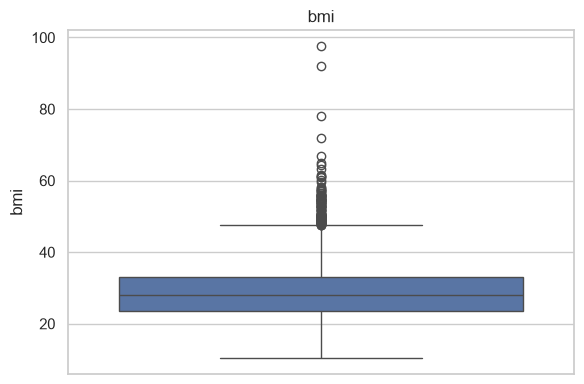

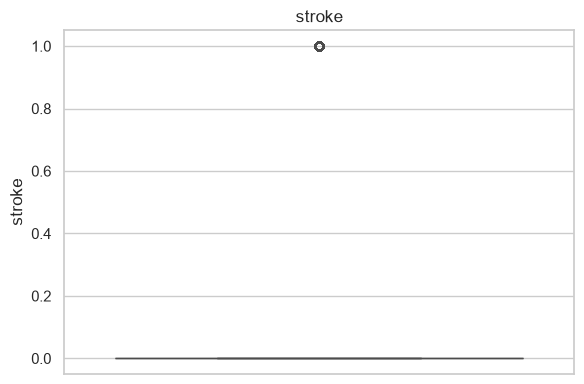

In [24]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        y = df[col]
    )

    plt.title(col)
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{col}_box.png"
    )

    plt.show()

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')


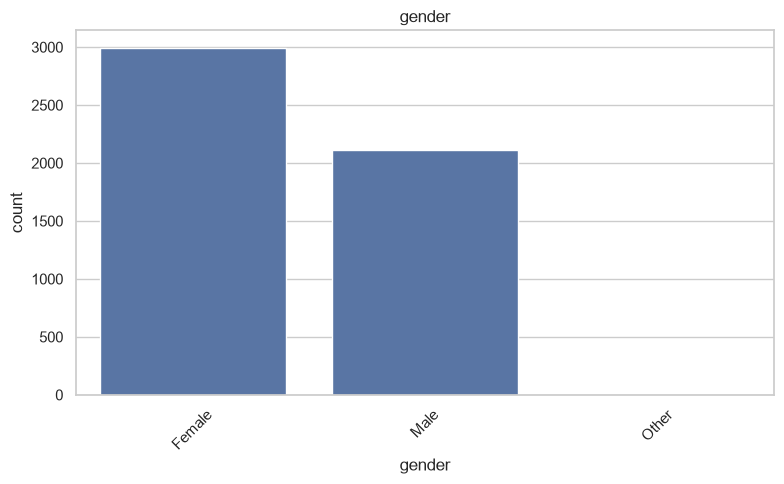

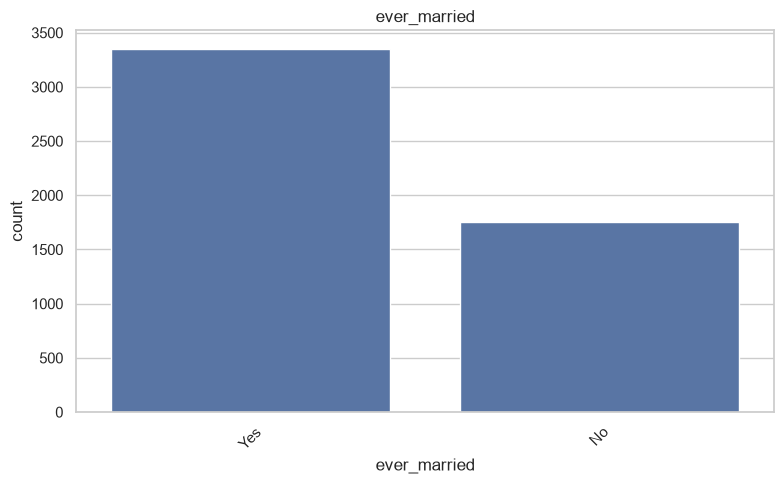

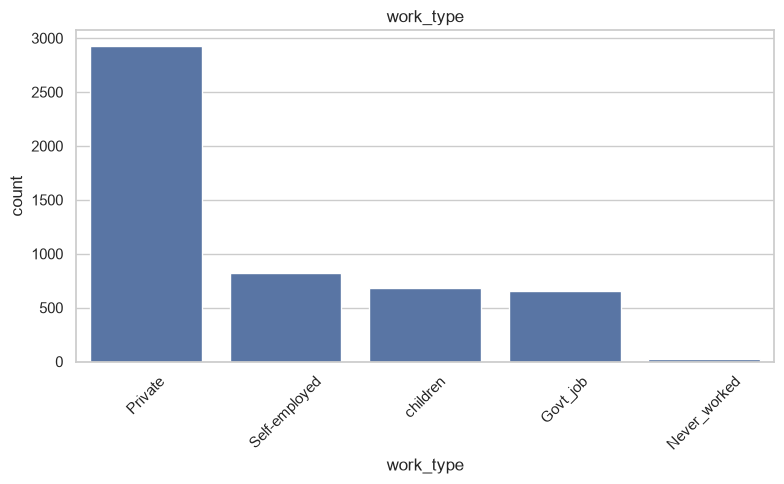

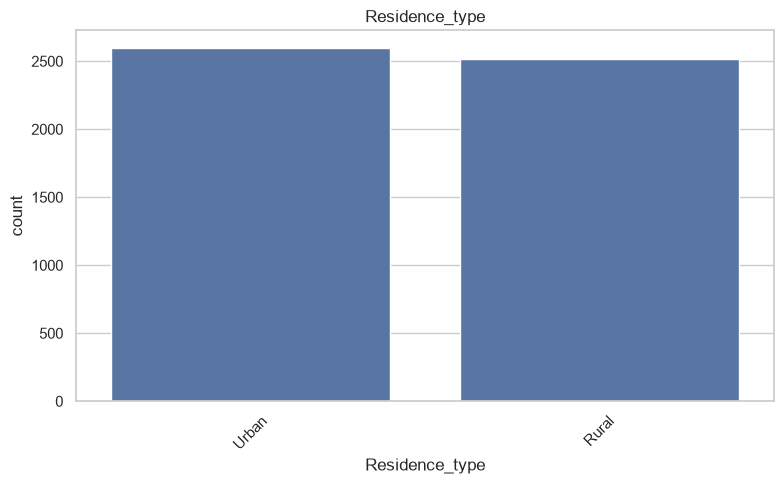

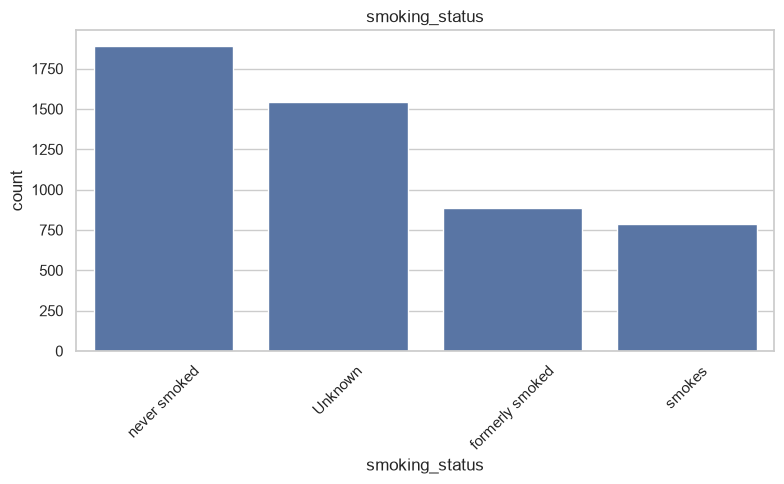

In [28]:
categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns

print(categorical_cols)

for col in categorical_cols:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data = df,
        x = col,
        order = df[col].value_counts().index
    )

    plt.xticks(rotation = 45)
    plt.title(col)
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{col}_count.png"
    )

    plt.show()

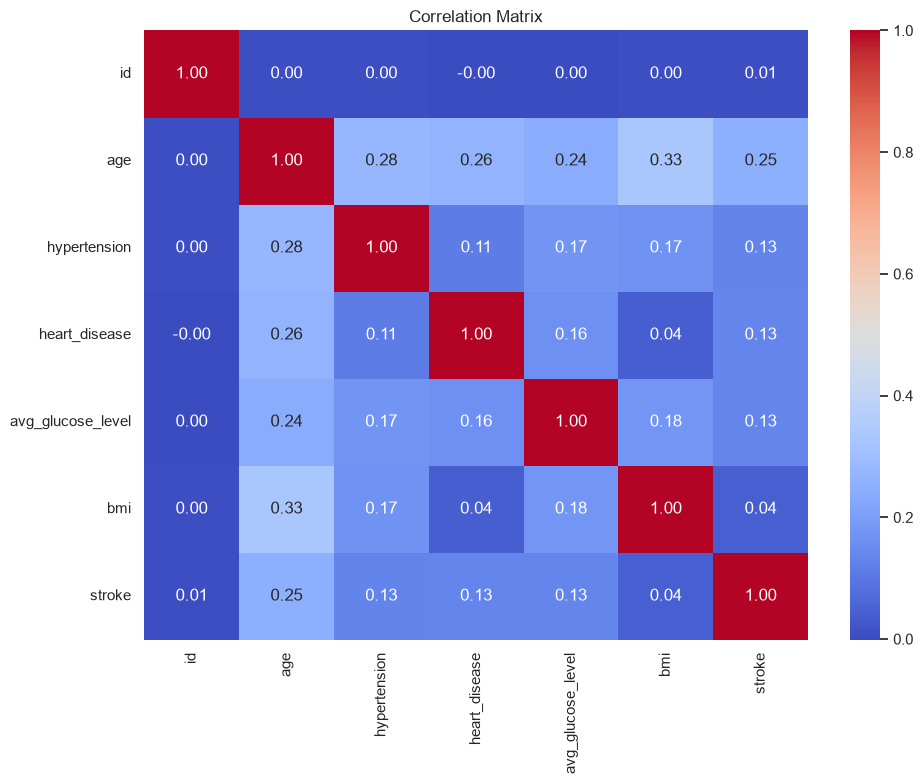

In [29]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr, 
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "correlation_matrix.png"
)

plt.show()

2026-07-06 20:21:33,972 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 20:21:33,980 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


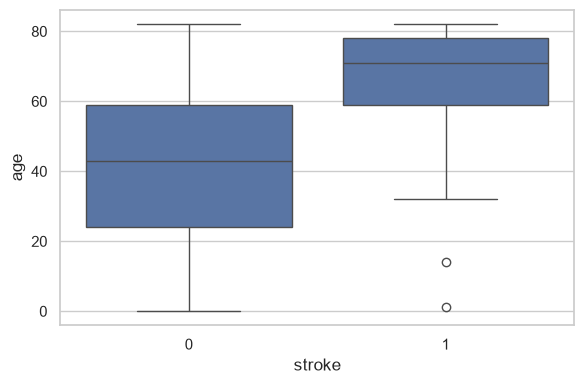

2026-07-06 20:21:34,085 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 20:21:34,089 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


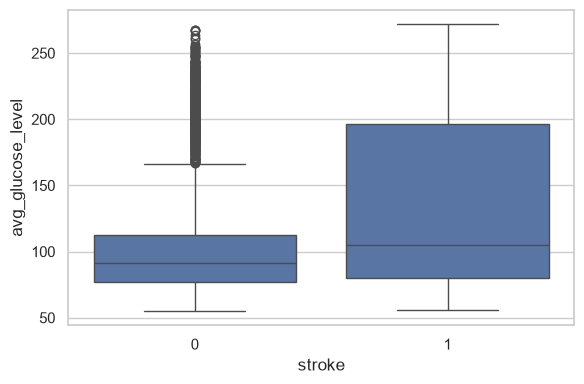

2026-07-06 20:21:34,197 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 20:21:34,203 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


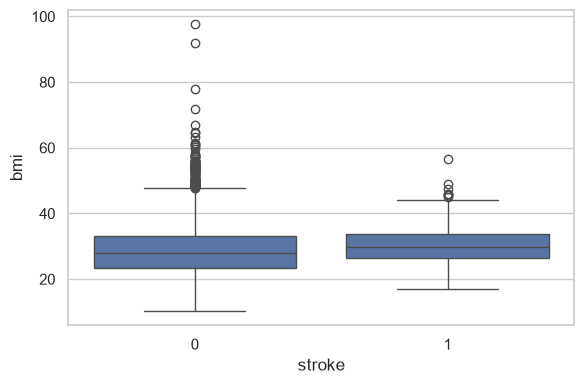

In [30]:
features = {
    "age",
    "bmi",
    "avg_glucose_level"
}

for feature in features:
    plt.figure(figsize = (6, 4))
    sns.boxplot(
        data = df, 
        x = "stroke",
        y = feature
    )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{feature}_vs_stroke.png"
    )

    plt.show()

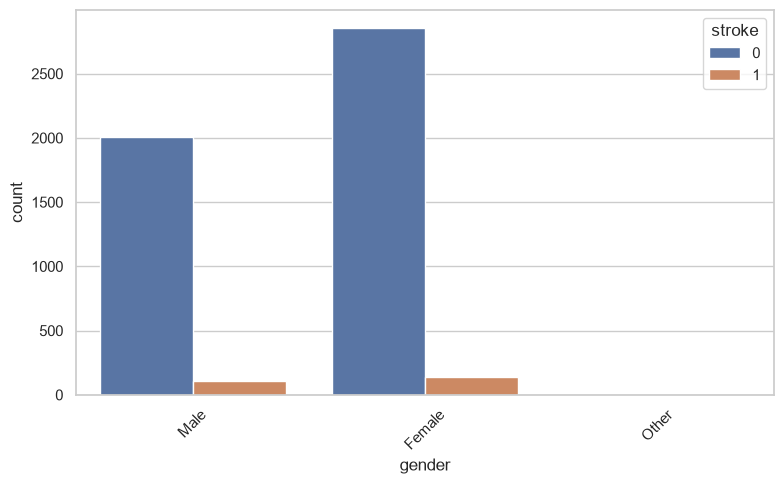

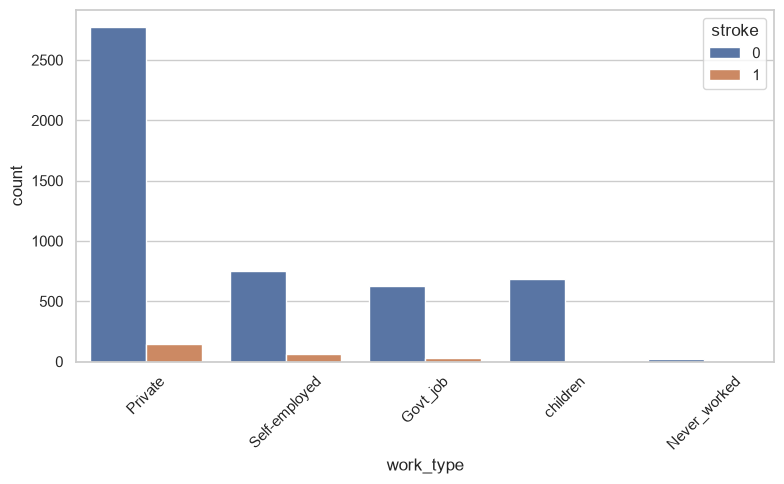

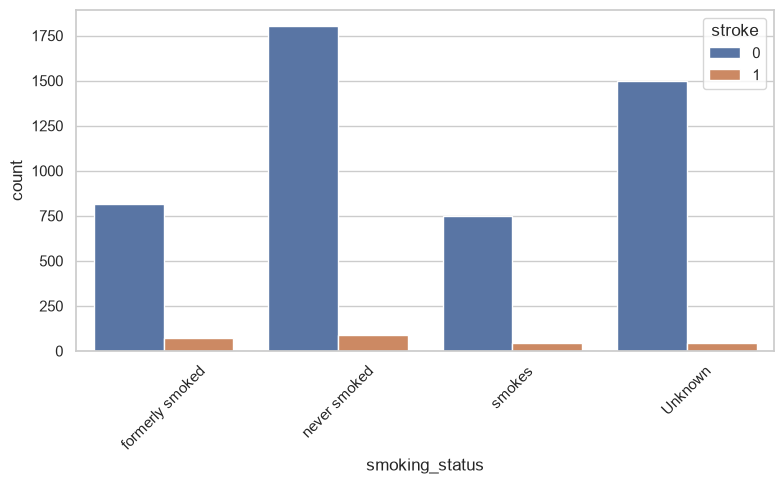

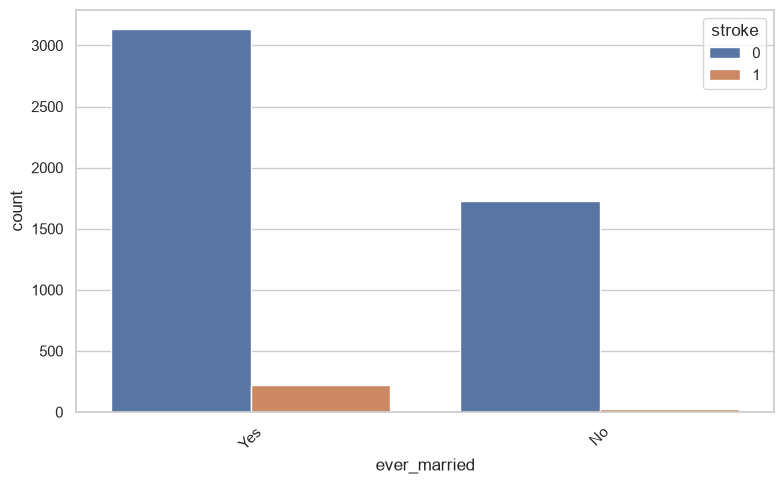

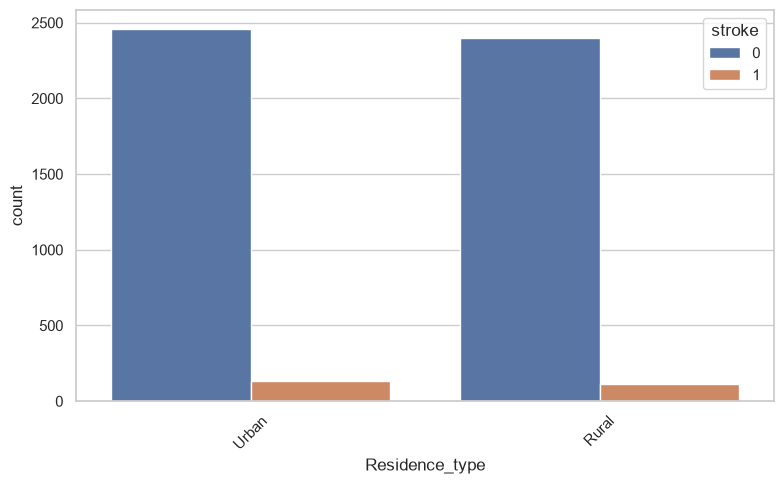

In [31]:
categorical = [
    "gender",
    "work_type",
    "smoking_status",
    "ever_married",
    "Residence_type"
]

for feature in categorical:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=feature,
        hue="stroke"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR /
        f"{feature}_stroke.png"
    )

    plt.show()

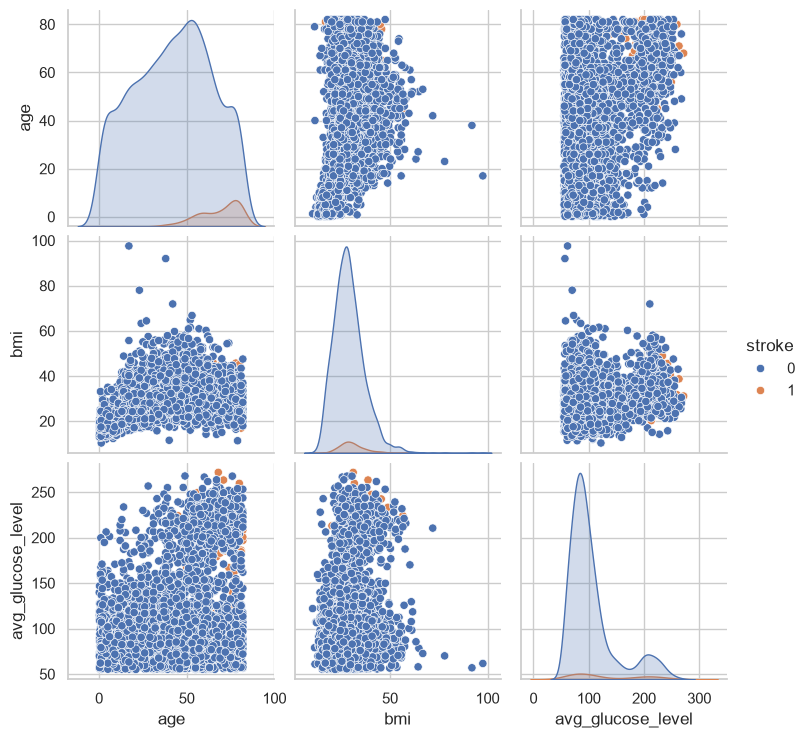

In [32]:
sns.pairplot(
    df[
        [
            "age",
            "bmi",
            "avg_glucose_level",
            "stroke"
        ]
    ],
    hue="stroke"
)